# ElbowSig tutorial

This notebook demonstrates the use of `ElbowSig`.

### Preliminaries

Calling necessary functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

import ElbowSig as ElbowSig


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

## Example with synthetic data

### Generating synthetic data:

Data consisting of 5 Gaussian components in 2 dimensions

Text(0, 0.5, '$x_2$')

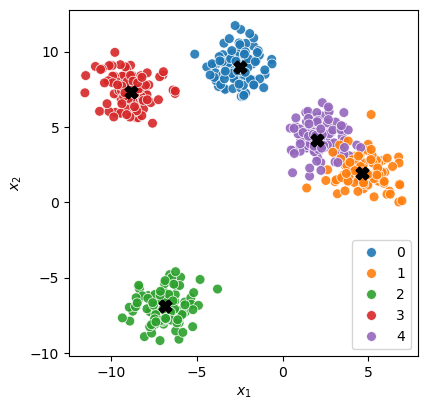

In [3]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns

# Synthetic data
X_blob, y_true, centers = make_blobs(
    n_samples=500, 
    centers=5, 
    cluster_std=1, 
    random_state=42,
    return_centers=True)


plt.figure(figsize=(4.5, 4.5))

sns.scatterplot(
    x=X_blob[:, 0], 
    y=X_blob[:, 1], 
    hue=y_true, 
    palette='tab10',#'magma',#'viridis', 
    legend='full',
    s=50,
    alpha=0.9#,
    #label='Generated Data Points'
)

# Plot the cluster centers (The ground truth)
plt.scatter(
    centers[:, 0], 
    centers[:, 1], 
    marker='X', 
    s=75, 
    color='black', 
    edgecolor='black',
    linewidth=1.5#,
    #label='Cluster Centers (Ground Truth)'
)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')


### Bounding-Box uniform unstructured reference data:

Text(0, 0.5, '$x_2$')

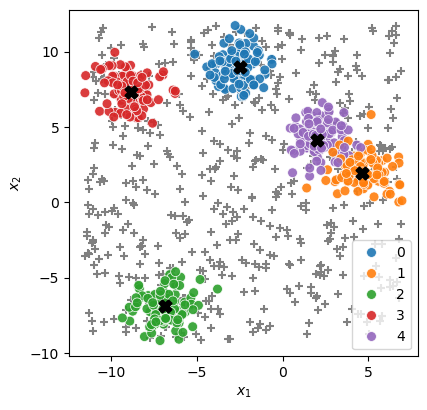

In [4]:
plt.figure(figsize=(4.5, 4.5))

ref_X = ElbowSig.data_random(X_blob)
plt.scatter(ref_X[:,0], ref_X[:,1], marker = '+', s=35, color='#808080') #, alpha=0.6)

sns.scatterplot(
    x=X_blob[:, 0], 
    y=X_blob[:, 1], 
    hue=y_true, 
    palette='tab10',#'magma',#'viridis', 
    legend='full',
    s=50,
    alpha=0.9#,
    #label='Generated Data Points'
)


# Plot the cluster centers (The ground truth)
plt.scatter(
    centers[:, 0], 
    centers[:, 1], 
    marker='X', 
    s=75, 
    color='black', 
    edgecolor='black',
    linewidth=1.5#,
    #label='Cluster Centers (Ground Truth)'
)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

### PCA-aligned unstructured reference data

Text(0, 0.5, '$x_2$')

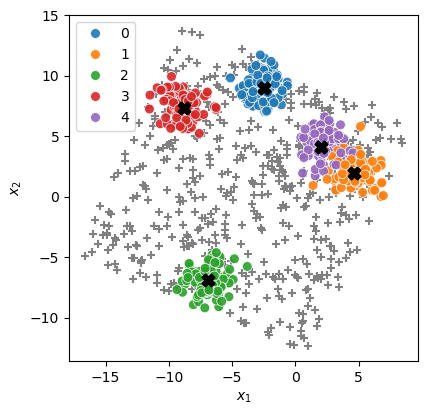

In [5]:
plt.figure(figsize=(4.5, 4.5))

ref_X = ElbowSig.data_random_pca_aligned(X_blob)
plt.scatter(ref_X[:,0], ref_X[:,1], marker = '+', s=35, color='#808080') #, alpha=0.6)

sns.scatterplot(
    x=X_blob[:, 0], 
    y=X_blob[:, 1], 
    hue=y_true, 
    palette='tab10',#'magma',#'viridis', 
    legend='full',
    s=50,
    alpha=0.9#,
    #label='Generated Data Points'
)


# Plot the cluster centers (The ground truth)
plt.scatter(
    centers[:, 0], 
    centers[:, 1], 
    marker='X', 
    s=75, 
    color='black', 
    edgecolor='black',
    linewidth=1.5#,
    #label='Cluster Centers (Ground Truth)'
)

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

### Agglomerative clustering

Agglomerative clustering using PCA-aligned unstructured reference data:

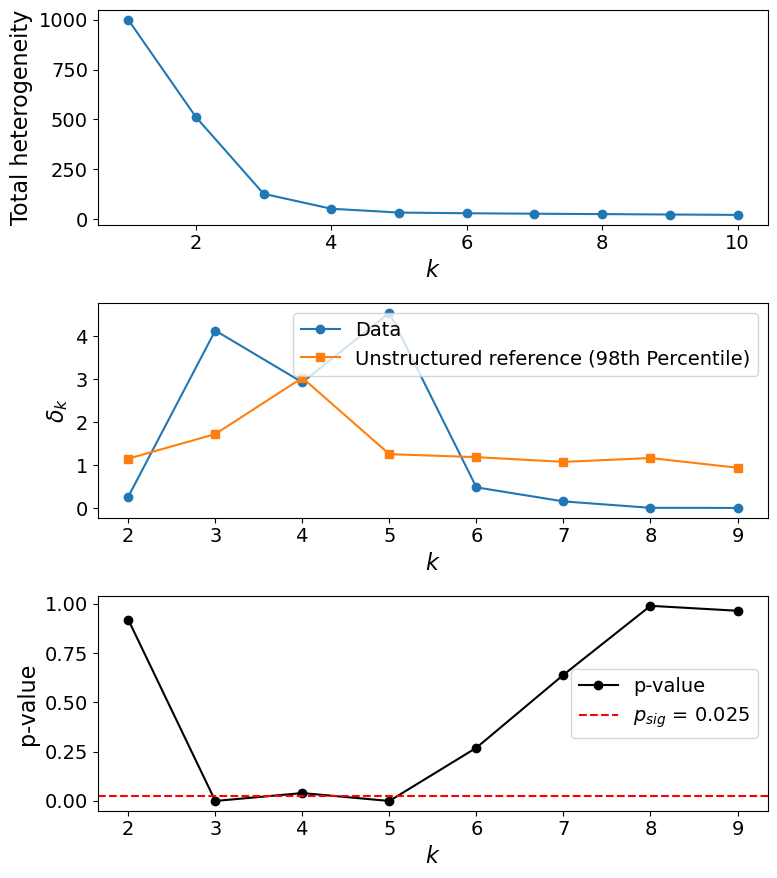

p-values:  [0.92  0.    0.04  0.    0.27  0.64  0.99  0.965]
p_values (BH): [0.99       0.         0.10666667 0.         0.54       0.99
 0.99       0.99      ]


In [ ]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out_agg_PCA = ElbowSig.Elbow_significance_general(
    X=X_blob,
    kmax=10,
    nr=200,
    qperk=0.05, qFDR=0.05,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.Agglomerative_Heterogeneity,
    pars=['euclidean', 'ward'], # Distance metric and linkage method
    random_data_func=ElbowSig.data_random_pca_aligned
)

print('p-values: ', out_agg_PCA['p_values'])

The plot presented above can be made a posteriori using `plot_Elbow_significance_general_results`

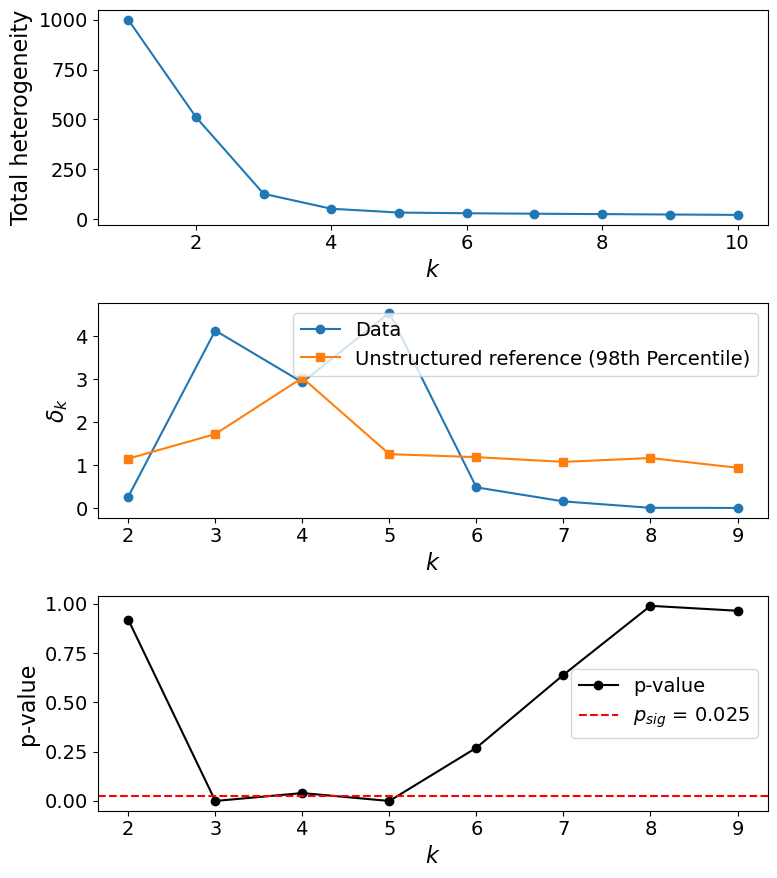

In [8]:
ElbowSig.plot_Elbow_significance_general_results(out_agg_PCA)

Graphical comparison of the observed $\delta_k$ and the distribution of $\delta_k$ for random unstructured reference data:

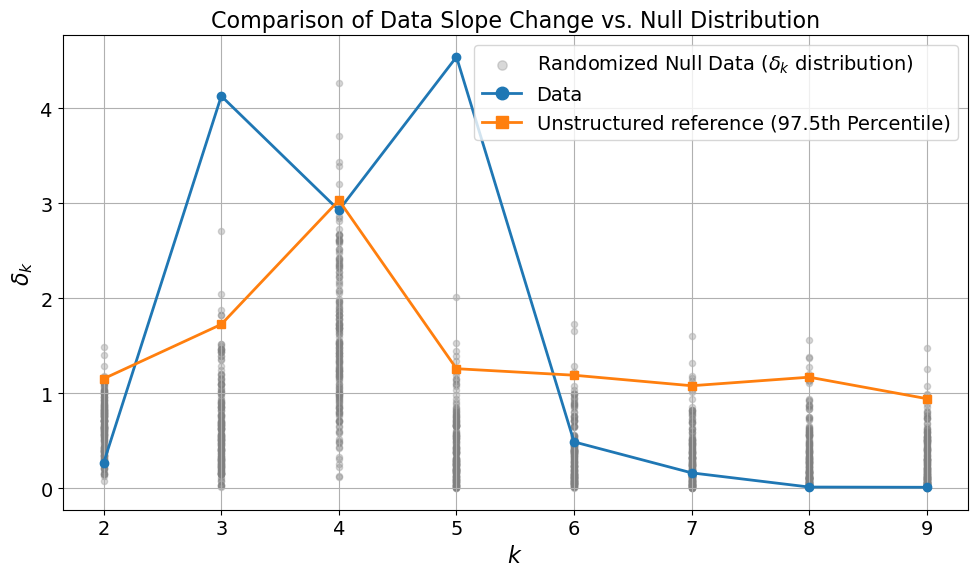

In [9]:
ElbowSig.compare_slope_changes_scatter_results(out_agg_PCA)

#### Visualizing the clusters for given $k$

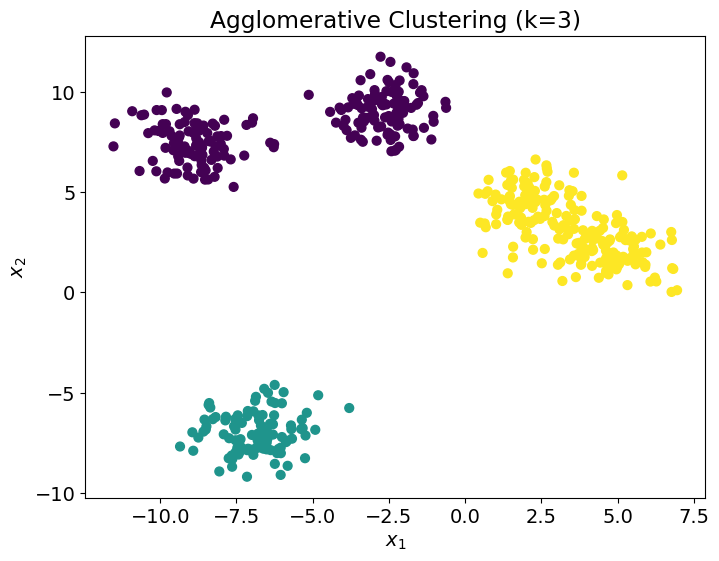

In [10]:
k = 3
ElbowSig.visualize_agglomerative_clustering(X_blob, k)

#### Exploring the output of the function `Elbow_significance_general`

Information in the `out` object

In [9]:
out.keys()

dict_keys(['k_values', 'hetero_k_stat', 'slope_change', 'percentile', 'p_values', 'k_optimal', 'slope_change_distribution', 'pv_thres_list', 'p_sig_thres'])

p-values

In [10]:
out['p_values']

array([0.965, 0.   , 0.045, 0.   , 0.305, 0.655, 0.965, 0.96 , 0.84 ,
       0.485, 0.245, 0.78 , 0.195, 0.11 , 0.785, 0.505])

Optimal k (list of statistically significant values of $k$, when controlling per-scale)

In [11]:
out['k_optimal']

[3, 5]

Threshold $p_{sig}$ for the p-value ensuring that a true null hypothesis (i.e. random unstructured data) would only be rejected with probability $q_1=0.05$ (set in `Elbow_significance_general` as `qperk=0.05`):

In [12]:
out['p_sig_thres']

0.02475

Values of $k$ for which $\text{p-value}<p_{sig}$:

In [13]:
out['k_values'][out['p_values']<out['p_sig_thres']]

array([3, 5])

Global False Discovery Rate (FDR) controlled p-values (Benjamini-Hochberg):

In [12]:
out_agg_PCA['p_values_corrected']

array([0.99      , 0.        , 0.10666667, 0.        , 0.54      ,
       0.99      , 0.99      , 0.99      ])

#### Gap statistic on these data using agglomerative clustering

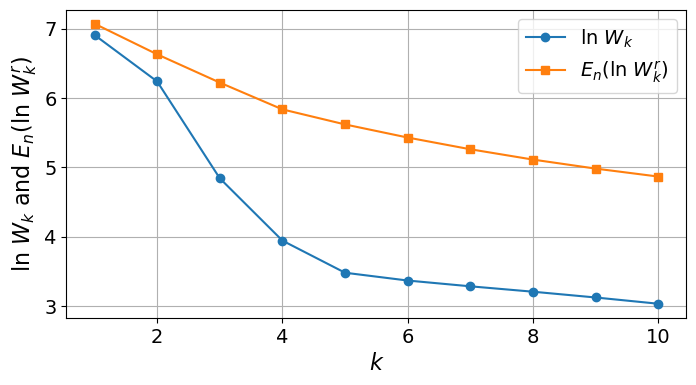

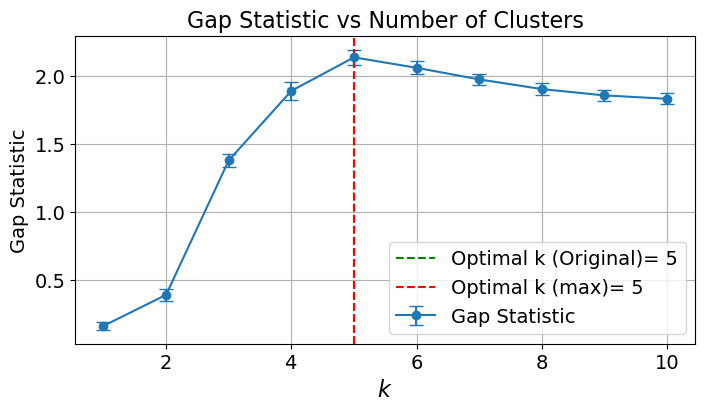

In [14]:
wcss_values, gap_values, sk_values, optimal_k_tibshirani, optimal_k_max_gap = ElbowSig.compute_gap_statistic(
    data0=X_blob, 
    max_k=10, 
    n_refs=200, 
    cluster_method="Agglomerate",
    random_data_func=ElbowSig.data_random_pca_aligned,
    plot=True
    )

### k-means

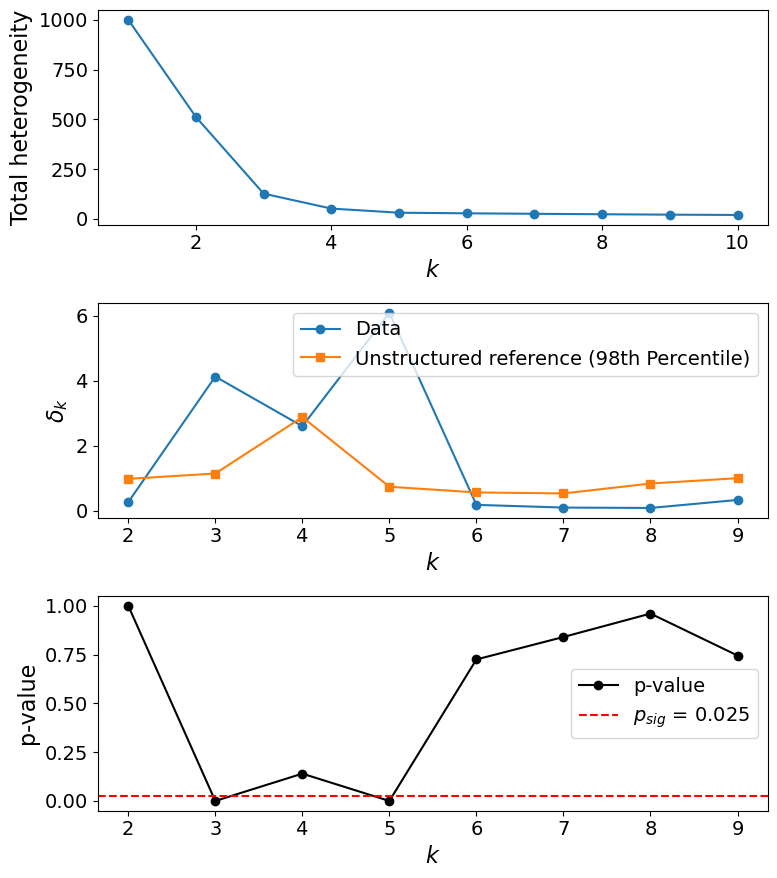

p-values:  [1.    0.    0.14  0.    0.725 0.84  0.96  0.745]


In [16]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out_kmeans_PCA = ElbowSig.Elbow_significance_general(
    X=X_blob,
    kmax=10,
    nr=200,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.Kmeans_Heterogeneity,
    pars=[10], #Number of initializations
    random_data_func=ElbowSig.data_random_pca_aligned
)

print('p-values: ', out_kmeans_PCA['p_values'])

### Fuzzy c-means

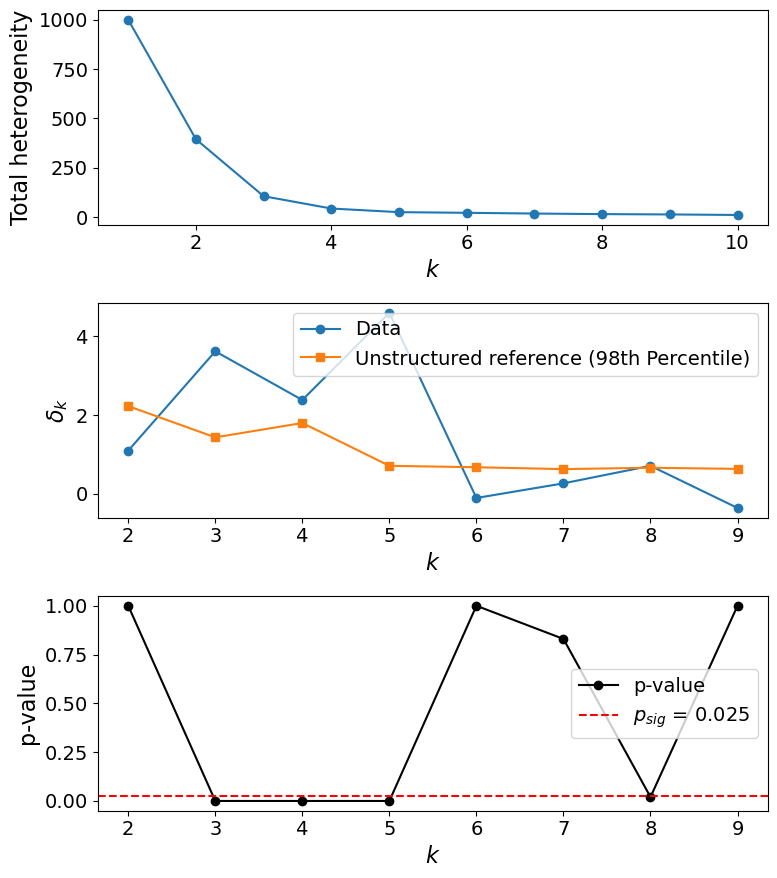

p-values:  [1.   0.   0.   0.   1.   0.83 0.02 1.  ]


In [ ]:
out_Fc_PCA = ElbowSig.Elbow_significance_general(
    X=X_blob,
    kmax=10,
    nr=200,
    plotYN='y',
    random_state=42,
    heterogeneity_func=ElbowSig.FCM_Heterogeneity,
    pars=[2, 0.005, 1000], # FCM parameters: fuzziness, error tolerance, max iterations
    random_data_func=ElbowSig.data_random_pca_aligned
)

#X, kmax=10, nr=100, alpha=0.05, plotYN=True, random_state=42, heterogeneity_func=FCM_Heterogeneity,pars=[2, 0.005, 1000]

print('p-values: ', out_Fc_PCA['p_values'])

### Gaussian Mixture Model

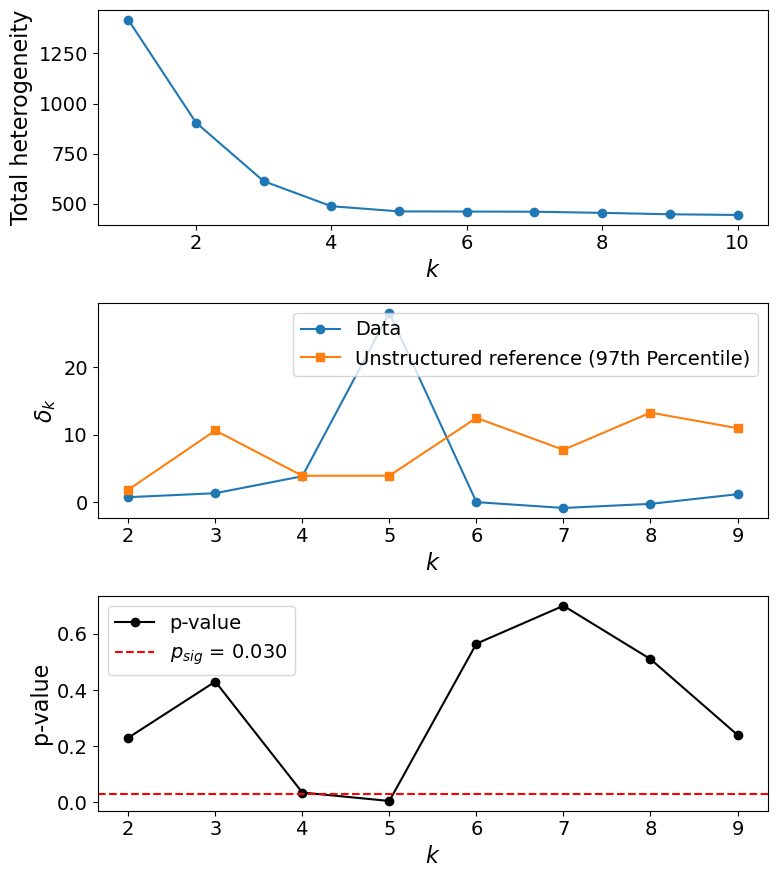

p-values:  [0.23  0.43  0.035 0.005 0.565 0.7   0.51  0.24 ]


In [ ]:
#k_values0, slope_change0, mean_slope_change, sd_slope_change, percentile, p_values, slope_change_distribution 
out_GMM_PCA = ElbowSig.Elbow_significance_general(
    X=X_blob,
    kmax=10,
    nr=200,
    plotYN='y',
    random_state=4,
    heterogeneity_func=ElbowSig.GMM_Heterogeneity,
    pars=['full'], # GMM parameters: covariance type
    random_data_func=ElbowSig.data_random_pca_aligned
)

#GMM_Heterogeneity(X, k, random_state=42, pars=['full'])

print('p-values: ', out_GMM_PCA['p_values'])